# Titanic Survival Analysis — Data Wrangling & Cleaning

## Objective

This notebook focuses on preprocessing and data quality assessment for the Titanic dataset.

The workflow includes:

- missing value analysis
- duplicate inspection
- outlier investigation
- feature relevance assessment
- preprocessing and cleaning operations

The objective is to prepare a structured and reliable dataset suitable for downstream exploratory analysis, feature engineering, and machine learning workflows.

## Import Required Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

sns.set_style('whitegrid')

%matplotlib inline

## Dataset Loading

The Titanic training dataset is loaded into a working dataframe for preprocessing and validation.

A copy of the original dataframe is created to preserve the integrity of the raw dataset throughout the cleaning workflow.


In [2]:
train_df = pd.read_csv('../data/raw/train.csv')

df = train_df.copy()

## Dataset Validation

A concise structural validation is performed to verify:

* dataset dimensions
* feature availability
* data types
* null observations

This establishes a reliable baseline before preprocessing operations are applied.


In [3]:
print(f'Dataset Shape: {df.shape}')

Dataset Shape: (891, 12)


In [4]:
df.columns.tolist()

['PassengerId',
 'Survived',
 'Pclass',
 'Name',
 'Sex',
 'Age',
 'SibSp',
 'Parch',
 'Ticket',
 'Fare',
 'Cabin',
 'Embarked']

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [6]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Initial Data Quality Summary

A preliminary data quality assessment is performed to identify:

* missing observations
* duplicate records
* datatype consistency
* structural irregularities

This provides an overview of preprocessing requirements before transformation operations are applied.


In [7]:
data_quality_summary = pd.DataFrame({
    'Data Type': df.dtypes,
    'Missing Values': df.isnull().sum(),
    'Missing Percentage': (
        df.isnull().sum() / len(df)
    ) * 100,
    'Unique Values': df.nunique()
})

data_quality_summary.sort_values(
    by='Missing Percentage',
    ascending=False
).style.background_gradient(
    cmap='Blues'
)


,Data Type,Missing Values,Missing Percentage,Unique Values
Cabin,str,687,77.104377,147
Age,float64,177,19.865320,88
Embarked,str,2,0.224467,3
PassengerId,int64,0,0.000000,891
Name,str,0,0.000000,891
Pclass,int64,0,0.000000,3
Survived,int64,0,0.000000,2
Sex,str,0,0.000000,2
Parch,int64,0,0.000000,7
SibSp,int64,0,0.000000,7


## Statistical Summary

A statistical summary is generated to evaluate:

* central tendency
* spread
* extreme observations
* feature scale differences

This assists in identifying skewness, unusual distributions, and potential outlier behavior.


In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
PassengerId,891.0,446.000000,257.353842,1.00,223.5000,446.0000,668.5,891.0000
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


## Missing Value Assessment

Missing data is evaluated to identify:

* incomplete observations
* feature-level sparsity
* preprocessing requirements

Incomplete data can negatively affect:

* statistical validity
* feature distributions
* machine learning model performance

The following analysis quantifies missing observations across the dataset.


In [9]:
missing_values = pd.DataFrame(
    {
        'Missing Values': df.isna().sum(),
        'Percentage': (df.isna().sum()/len(df)) * 100
    }
)

missing_values = missing_values[missing_values['Missing Values'] > 0]

missing_values.sort_values(
    by = 'Percentage', 
    ascending = False
)

missing_values.style.background_gradient(
    cmap='Reds'
)


,Missing Values,Percentage
Age,177,19.865320
Cabin,687,77.104377
Embarked,2,0.224467


## Missing Data Visualization

Visual inspection helps identify structural missingness patterns across the dataset.

This assists in distinguishing:

* isolated missing observations
* feature-wide sparsity
* potential systematic missingness


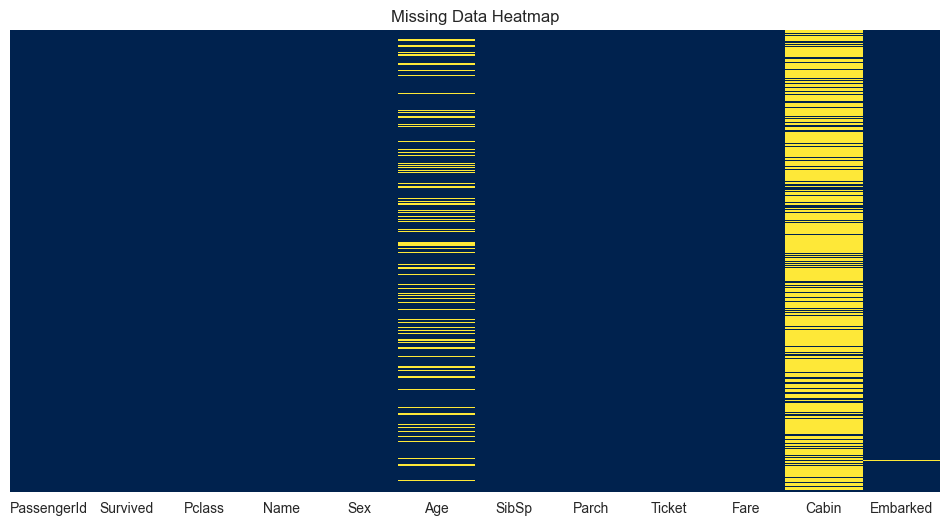

In [10]:
plt.figure(figsize = (12, 6))

sns.heatmap(
    df.isna(),
    cbar = False,
    yticklabels = False,
    cmap = 'cividis'
)

plt.title('Missing Data Heatmap')

plt.show()

## Feature-Level Missing Data Analysis

Missing features are evaluated individually to determine:

* statistical relevance
* degree of sparsity
* appropriate preprocessing strategy


### Cabin

The `Cabin` feature contains a substantial proportion of missing observations.

Due to the high degree of sparsity and the absence of reliable direct imputation strategies at this stage, the feature will be excluded from the baseline preprocessing workflow.

The feature may later support engineered variables such as deck extraction.


In [11]:
cabin_missing_percentage = (
    df['Cabin'].isna().mean()
) * 100

print(
    f'Cabin Missing Percentage: {cabin_missing_percentage: .2f}%'
)

Cabin Missing Percentage:  77.10%


### Age

The `Age` feature contains moderate missingness and remains statistically important for survival analysis.

Median imputation is selected because:

* the distribution is skewed
* the median is robust against extreme values
* it preserves central tendency more effectively than mean imputation


In [12]:
age_missing_percentage = (
    df['Age'].isnull().mean()
) * 100

print(
    f'Age Missing Percentage: {age_missing_percentage: .2f}%'
)

Age Missing Percentage:  19.87%


### Embarked

The `Embarked` feature contains a minimal number of missing observations.

Mode imputation is appropriate because:

* the feature is categorical
* missingness is negligible
* it minimizes distributional distortion


In [13]:
embarked_missing_percentage = (
    df['Embarked'].isnull().mean()
) * 100

print(
    f'Embarked Missing Percentage: {embarked_missing_percentage: .2f}%'
)

Embarked Missing Percentage:  0.22%


## Duplicate Record Analysis

Duplicate observations can negatively affect:

* statistical distributions
* feature relationships
* machine learning model behavior

The dataset is evaluated for exact duplicate records before preprocessing operations are applied.


In [14]:
duplicates = df.duplicated().sum()

print(f'Total Duplicated Rows: {duplicates}')

Total Duplicated Rows: 0


The dataset does not contain exact duplicate observations. No duplicate removal operations were required during preprocessing.


## Feature Distribution Analysis

Distribution analysis is performed to evaluate:

* skewness
* concentration
* spread
* potential anomalies

Understanding feature distributions is important for preprocessing decisions and downstream model behavior.


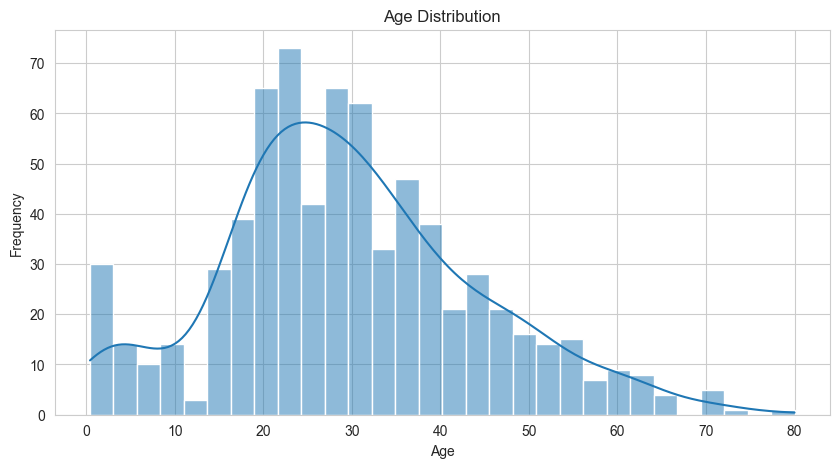

In [15]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df['Age'],
    bins=30,
    kde=True
)

plt.title('Age Distribution')

plt.xlabel('Age')
plt.ylabel('Frequency')

plt.show()

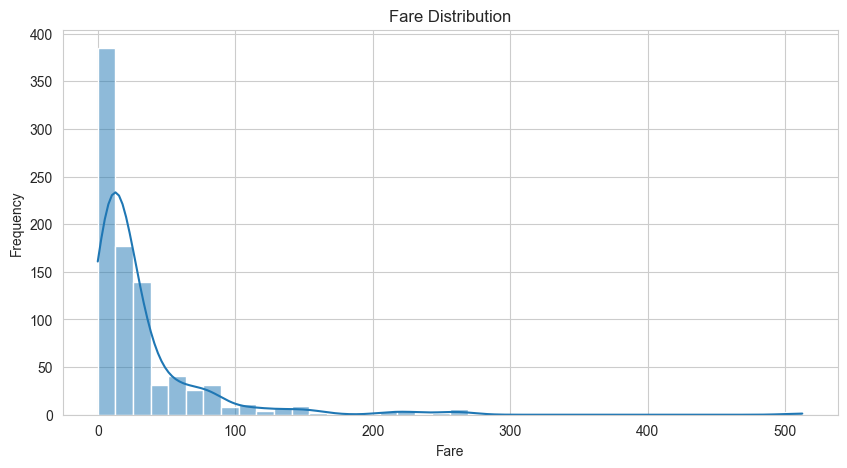

In [16]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df['Fare'],
    bins=40,
    kde=True
)

plt.title('Fare Distribution')

plt.xlabel('Fare')
plt.ylabel('Frequency')

plt.show()

## Skewness Assessment

Feature skewness is evaluated to identify asymmetric distributions that may influence:

* preprocessing strategy
* statistical interpretation
* model sensitivity


In [17]:
numeric_features = [
    'Age',
    'Fare',
    'SibSp',
    'Parch'
]

df[numeric_features].skew().sort_values(
    ascending=False
)

Fare     4.787317
SibSp    3.695352
Parch    2.749117
Age      0.389108
dtype: float64

## Outlier Investigation

Outlier analysis is performed to identify unusually extreme observations that may disproportionately influence statistical measures and model behavior.

Primary focus:

* Fare
* Age

Visual inspection and IQR-based analysis are used to evaluate extreme observations.


### Fare Boxplot Analysis

A boxplot representation of the `Fare` feature is used to visually confirm:

* distributional spread
* skewness behavior
* concentration of lower fare observations
* presence of extreme values identified during outlier analysis

The visualization complements the earlier histogram-based distribution assessment.


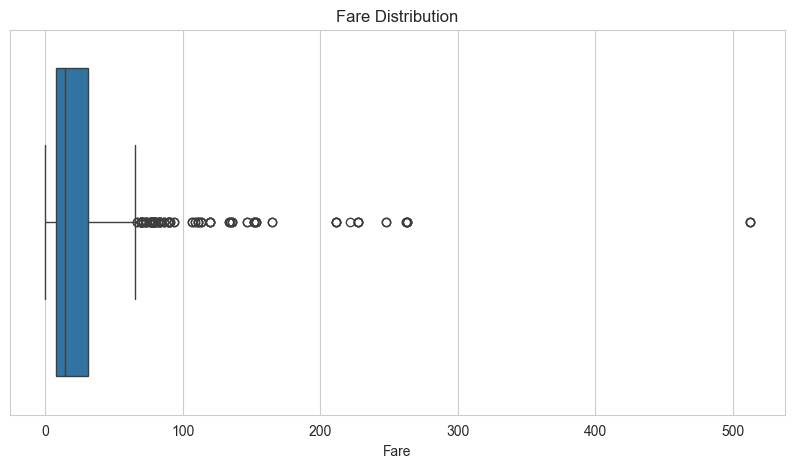

In [18]:
plt.figure(figsize=(10, 5))

sns.boxplot(x=df['Fare'])

plt.title('Fare Distribution')

plt.show()

### Age Boxplot Analysis

A boxplot representation of the `Age` feature is used to evaluate:

* spread of passenger ages
* concentration around central values
* potential extreme observations
* overall distribution consistency

The visualization supports the earlier statistical and distribution-based assessments.


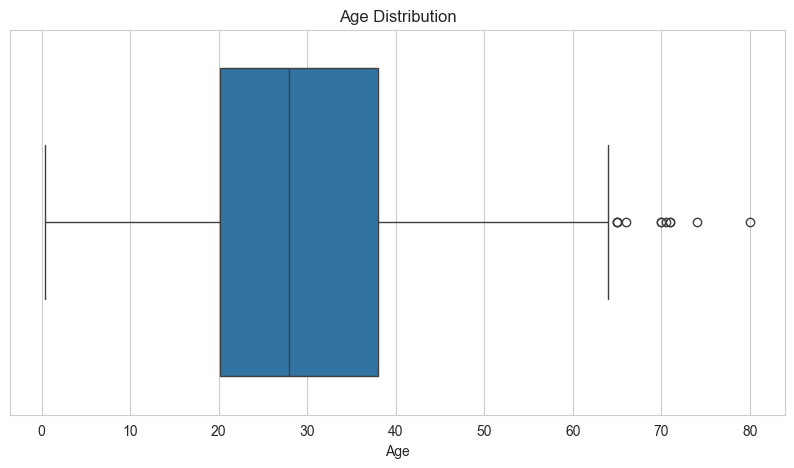

In [19]:
plt.figure(figsize=(10, 5))

sns.boxplot(x=df['Age'])

plt.title('Age Distribution')

plt.show()

## IQR-Based Outlier Detection

The Interquartile Range (IQR) method is used to quantify extreme observations within the `Fare` feature.

The method defines outliers as observations falling outside:

* Q1 − 1.5 × IQR
* Q3 + 1.5 × IQR


In [20]:
Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

fare_outliers = df[
    (df['Fare'] < lower_bound) |
    (df['Fare'] > upper_bound)
]

print(
    f'Number of Fare Outliers: {fare_outliers.shape[0]}'
)

Number of Fare Outliers: 116


### Outlier Inspection

The identified fare outliers are reviewed directly to determine whether the observations represent:

* data quality issues
* recording errors
* or legitimate high-value passenger records


In [21]:
fare_outliers.sort_values(
    by='Fare',
    ascending=False
).head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
258,259,1,1,"Ward, Miss. Anna",female,35.0,0,0,PC 17755,512.3292,NaN,C
737,738,1,1,"Lesurer, Mr. Gustave J",male,35.0,0,0,PC 17755,512.3292,B101,C
679,680,1,1,"Cardeza, Mr. Thomas Drake Martinez",male,36.0,0,1,PC 17755,512.3292,B51 B53 B55,C
27,28,0,1,"Fortune, Mr. Charles Alexander",male,19.0,3,2,19950,263.0000,C23 C25 C27,S
341,342,1,1,"Fortune, Miss. Alice Elizabeth",female,24.0,3,2,19950,263.0000,C23 C25 C27,S
438,439,0,1,"Fortune, Mr. Mark",male,64.0,1,4,19950,263.0000,C23 C25 C27,S
88,89,1,1,"Fortune, Miss. Mabel Helen",female,23.0,3,2,19950,263.0000,C23 C25 C27,S
311,312,1,1,"Ryerson, Miss. Emily Borie",female,18.0,2,2,PC 17608,262.3750,B57 B59 B63 B66,C
742,743,1,1,"Ryerson, Miss. Susan Parker ""Suzette""",female,21.0,2,2,PC 17608,262.3750,B57 B59 B63 B66,C
299,300,1,1,"Baxter, Mrs. James (Helene DeLaudeniere Chaput)",female,50.0,0,1,PC 17558,247.5208,B58 B60,C


### Outlier Interpretation

The identified fare outliers primarily represent passengers with unusually high ticket fares.

These observations are retained because:

* they appear to be legitimate records
* they may contain valuable socioeconomic signal
* removal could distort class-related survival patterns

No outlier removal is performed at this stage.


## Data Leakage Consideration

Preprocessing operations in this notebook are intentionally applied during the exploratory phase prior to model development.

Future modeling workflows should ensure that:

* train-test splitting occurs before model-dependent preprocessing operations
* transformations are fit exclusively on training data
* evaluation datasets remain isolated to prevent data leakage


## Missing Value Treatment

The following preprocessing operations are applied:

* median imputation for `Age`
* mode imputation for `Embarked`
* exclusion of `Cabin`

These decisions are based on:

* feature sparsity
* distributional characteristics
* statistical relevance


### Median Imputation — Age

Median imputation is applied to the `Age` feature to preserve statistical stability while minimizing sensitivity to extreme observations.


In [22]:
df['Age'] = df['Age'].fillna(df['Age'].median())

df['Age']

0      22.00
1      38.00
2      26.00
3      35.00
4      35.00
5      28.00
6      54.00
7       2.00
8      27.00
9      14.00
10      4.00
11     58.00
12     20.00
13     39.00
14     14.00
15     55.00
16      2.00
17     28.00
18     31.00
19     28.00
20     35.00
21     34.00
22     15.00
23     28.00
24      8.00
25     38.00
26     28.00
27     19.00
28     28.00
29     28.00
30     40.00
31     28.00
32     28.00
33     66.00
34     28.00
35     42.00
36     28.00
37     21.00
38     18.00
39     14.00
40     40.00
41     27.00
42     28.00
43      3.00
44     19.00
45     28.00
46     28.00
47     28.00
48     28.00
49     18.00
50      7.00
51     21.00
52     49.00
53     29.00
54     65.00
55     28.00
56     21.00
57     28.50
58      5.00
59     11.00
60     22.00
61     38.00
62     45.00
63      4.00
64     28.00
65     28.00
66     29.00
67     19.00
68     17.00
69     26.00
70     32.00
71     16.00
72     21.00
73     26.00
74     32.00
75     25.00
76     28.00

### Mode Imputation — Embarked

Mode imputation is applied to the `Embarked` feature because the feature is categorical and contains minimal missingness.


In [23]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

df['Embarked']

0      S
1      C
2      S
3      S
4      S
5      Q
6      S
7      S
8      S
9      C
10     S
11     S
12     S
13     S
14     S
15     S
16     Q
17     S
18     S
19     C
20     S
21     S
22     Q
23     S
24     S
25     S
26     C
27     S
28     Q
29     S
30     C
31     C
32     Q
33     S
34     C
35     S
36     C
37     S
38     S
39     C
40     S
41     S
42     C
43     C
44     Q
45     S
46     Q
47     Q
48     C
49     S
50     S
51     S
52     C
53     S
54     C
55     S
56     S
57     C
58     S
59     S
60     C
61     S
62     S
63     S
64     C
65     C
66     S
67     S
68     S
69     S
70     S
71     S
72     S
73     C
74     S
75     S
76     S
77     S
78     S
79     S
80     S
81     S
82     Q
83     S
84     S
85     S
86     S
87     S
88     S
89     S
90     S
91     S
92     S
93     S
94     S
95     S
96     C
97     C
98     S
99     S
100    S
101    S
102    S
103    S
104    S
105    S
106    S
107    S
108    S
109    Q
110    S
1

### Feature Exclusion — Cabin

The `Cabin` feature is excluded from the baseline preprocessing workflow due to substantial sparsity and limited direct usability in its raw form.


In [24]:
df.drop(
    columns='Cabin',
    inplace=True
)

## Feature Relevance Assessment

Several features are evaluated for predictive relevance and structural utility within the baseline modeling workflow.


### PassengerId

`PassengerId` functions solely as a unique identifier and does not contribute meaningful predictive signal.

The feature is excluded from the modeling dataset.


In [25]:
df.drop(
    columns='PassengerId',
    inplace=True
)

### Ticket

The `Ticket` feature contains highly irregular categorical patterns and limited direct interpretability in its raw form.

The feature is excluded from the baseline preprocessing workflow.


In [26]:
df.drop(
    columns='Ticket',
    inplace=True
)

## Post-Cleaning Validation

A post-cleaning validation is performed to confirm:

* successful preprocessing
* removal of targeted inconsistencies
* absence of unresolved missing values


In [27]:
df.isnull().sum()

Survived    0
Pclass      0
Name        0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

### Dataset Shape Comparison

Dataset dimensions are compared before and after preprocessing to evaluate the structural impact of cleaning operations.


In [28]:
print('Original Shape :', train_df.shape)
print('Cleaned Shape  :', df.shape)

Original Shape : (891, 12)
Cleaned Shape  : (891, 9)


In [29]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    str    
 3   Sex       891 non-null    str    
 4   Age       891 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Fare      891 non-null    float64
 8   Embarked  891 non-null    str    
dtypes: float64(2), int64(4), str(3)
memory usage: 62.8 KB


The preprocessing workflow was intentionally implemented in a transparent step-by-step manner to maximize interpretability and analytical traceability during the exploratory phase of the project.

Future iterations may transition preprocessing operations into reusable pipeline-based workflows.


## Export Cleaned Dataset

The cleaned dataset is exported for downstream:

* exploratory analysis
* feature engineering
* machine learning workflows


In [30]:
df.to_csv(
    '../data/processed/titanic_cleaned.csv',
    index=False
)

## Preprocessing Decision Summary

| Feature     | Issue Identified                               | Action Taken      |
| ----------- | ---------------------------------------------- | ----------------- |
| Age         | Missing values                                 | Median imputation |
| Embarked    | Missing values                                 | Mode imputation   |
| Cabin       | Severe sparsity                                | Feature removed   |
| PassengerId | Identifier-only feature                        | Feature removed   |
| Ticket      | High-cardinality irregular categorical feature | Feature removed   |


## Final Summary

The preprocessing workflow addressed:

* missing data
* structural inconsistencies
* duplicate inspection
* feature relevance assessment
* preliminary outlier analysis

Key preprocessing decisions:

* median imputation for `Age`
* mode imputation for `Embarked`
* exclusion of `Cabin`
* exclusion of low-utility identifier-based features

The resulting dataset is now suitable for:

* exploratory data analysis
* feature engineering
* machine learning model development
* statistical evaluation workflows
